In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [6]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_35836\1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [7]:
samples_df, cns_df = cdu.main_load("COSMIC_with_fill")

In [8]:
cns_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
cns_df["sample_id"] = "mean LUSC CN"

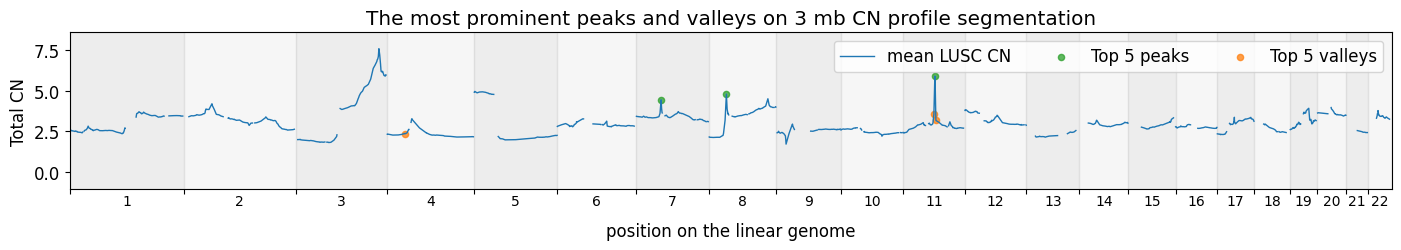

In [13]:
cns_df["score"] = cns.calc_angles(cns_df, "total_cn")

feature = "score"
val_count = 3
sorted_pos = np.argsort(cns_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn", colors=color_map[0])
cns_df = cns.add_cum_mid(cns_df)
fig.set_size_inches(14, 2)

ax.scatter(cns_df["cum_mid"].iloc[top_vals], cns_df["total_cn"].iloc[top_vals], color=color_map[2], alpha=0.75, s=20, label="Top 5 peaks")
ax.scatter(cns_df["cum_mid"].iloc[bot_vals], cns_df["total_cn"].iloc[bot_vals], color=color_map[1], alpha=0.75, s=20, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="upper right", ncol=3)

cdu.save_cns_fig("3MB_cns_peaks_valleys")

In [14]:
selection_df = cns_df[~cns_df["name"].str.startswith("chr")].sort_values(by="score")
selection_df

,chrom,start,end,name,major_cn,minor_cn,total_cn,sample_id,score,cum_mid
1316,chr8,38268655,38326352,FGFR1,3.723610,1.059167,4.782777,mean LUSC CN,-2.349156,1431093193
250,chr11,69455854,69469242,CCND1,4.682949,1.201807,5.884757,mean LUSC CN,-2.061607,1885370438
1256,chr7,55086713,55324313,EGFR,3.072917,1.360901,4.433818,mean LUSC CN,-1.574381,1288862540
252,chr11,70049268,70053496,FADD,4.444354,1.195783,5.640137,mean LUSC CN,-1.478787,1885959272
1026,chr3,181429713,181432221,SOX2,5.761044,1.800201,7.561245,mean LUSC CN,-1.133718,673880961
...,...,...,...,...,...,...,...,...,...,...
1032,chr3,185764096,185828107,ETV5,4.576909,1.706365,6.283274,mean LUSC CN,0.745089,678246095
599,chr17,37921197,38020441,IKZF3,2.269714,0.955249,3.224964,mean LUSC CN,0.966405,2538142683
1390,chr9,21967750,21995300,CDKN2A,1.579756,0.147157,1.726912,mean LUSC CN,1.130200,1561141237
1056,chr4,40192672,40248587,RHOH,1.727594,0.638554,2.366148,mean LUSC CN,1.372987,730693053


In [16]:
selection_df.query("chrom == 'chr3'")

,chrom,start,end,name,major_cn,minor_cn,total_cn,sample_id,score,cum_mid
1026,chr3,181429713,181432221,SOX2,5.761044,1.800201,7.561245,mean LUSC CN,-1.133718,673880961
1046,chr3,195754053,195809060,TFRC,4.294898,1.667671,5.962569,mean LUSC CN,-0.755653,688231550
1030,chr3,185361526,185542844,IGF2BP2,4.738830,1.718823,6.457654,mean LUSC CN,-0.642155,677902179
1028,chr3,185000728,185206885,MAP3K13,4.852308,1.730944,6.583252,mean LUSC CN,-0.487862,677553800
1040,chr3,189349204,189615068,TP63,4.475258,1.706496,6.181753,mean LUSC CN,-0.242369,681932130
1020,chr3,168801286,169381406,MECOM,4.624897,1.734984,6.359881,mean LUSC CN,-0.130477,661541340
1014,chr3,149235021,149454501,WWTR1,3.617977,1.575348,5.193325,mean LUSC CN,-0.079240,641794755
1000,chr3,128198269,128212028,GATA2,2.695783,1.389558,4.085341,mean LUSC CN,-0.078990,620655142
1012,chr3,142168076,142297668,ATR,3.345401,1.525089,4.870490,mean LUSC CN,-0.038230,634682866
950,chr3,10182691,10193904,VHL,1.873494,0.134538,2.008032,mean LUSC CN,-0.027010,502638291
